# **Chapter 18: 隠れ層とReLU**

## 1本の直線では分けにくい模様を学習する

前回までは、49個の画素から10個の数字スコアへ、1回の線形変換で直接つないでいました。

今回は、その間に25個の隠れ層を置き、ReLUを挟みます。隠れ層は画素のまとまりから特徴を見つけ、ReLUは負の反応を0にして、より複雑な境界を表せるようにします。

つまり、$49 \rightarrow 10$ だったモデルを、$49 \rightarrow 25 \rightarrow 10$ へ拡張します。

Chapter 18では、この新しい構造を学習させ、隠れ層の各ノードがどのような模様に反応するのかを可視化します。


![input to output](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-network.svg)


In [2]:
# テンソルを見やすく表示するライブラリをインストール
!pip install git+https://github.com/HayatoHongo/print_formatted_tensor.git
# PyTorchのテンソルを見やすく表示する関数をインポート
from torch_print_tensor import print_formatted_tensor

  Cloning https://github.com/HayatoHongo/print_formatted_tensor.git to /private/var/folders/jt/5_z36q1n1sg3hfdfbkzytlyh0000gn/T/pip-req-build-ckvpz4u6
  Running command git clone --filter=blob:none --quiet https://github.com/HayatoHongo/print_formatted_tensor.git /private/var/folders/jt/5_z36q1n1sg3hfdfbkzytlyh0000gn/T/pip-req-build-ckvpz4u6
  Resolved https://github.com/HayatoHongo/print_formatted_tensor.git to commit bd6142ed11d910b7f2cf514ec385ab05970b064e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 25.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import torch

torch.nn は何度も使うので、ここからは nn という短い名前で呼ぶ

```python
import torch.nn as nn
```

In [4]:
import torch.nn as nn # TODO: import torch.nn as nn
test_model = nn.Linear(1, 1, bias=False) # import が失敗しているとエラーが発生する

`torch.optim` も何度も使うので、ここからは `optim` という短い名前で呼ぶ


```python
import torch.optim as optim
```


In [5]:
import torch.optim as optim  # TODO: import torch.optim as optim
test_optimizer = optim.SGD([test_model.weight], lr=0.1)  # import が失敗しているとエラーが発生する

## **Section 1: 画像と正解ラベルを取り出す**
**Mission: モデルへ渡す入力 $X$ と正解 $y$ を用意する！**

この章では、数字画像を1列に並べた入力を使います。画像は $7 × 7$ ピクセルなので、1枚の入力は $49$ 個の数値です。

データには $1000$ 枚の画像があり、各画像は $49$ 個の画素値として並んでいます。$X$ は画像、$y$ は正しい数字の番号、$Y$ は正解を10個の要素で表した形式です。

モデルが見るのは画像の並びですが、損失を計算するときは正解ラベル $y$ と照合します。


データをダウンロードする


In [6]:
!wget https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/mnist_7x7_shuffled_difficult_1000.pt


zsh:1: command not found: wget


### データを読む
`torch.load` は、保存済みのデータを読み込む命令です。


保存したデータを読み込みましょう。

```python
出力: data（画像と正解をまとめたデータ）
関数: torch.load
引数: "mnist_7x7_shuffled_difficult_1000.pt"
```


In [7]:
data = torch.load("mnist_7x7_shuffled_difficult_1000.pt")  # TODO: 出力 = 関数(引数)
print("data", data)


data {'X': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), 'y': tensor([3, 1, 4, 0, 2, 3, 0, 7, 8, 0, 9, 2, 4, 9, 8, 2, 8, 6, 3, 2, 0, 2, 2, 1,
        7, 5, 0, 4, 5, 0, 7, 8, 3, 5, 0, 9, 2, 1, 8, 6, 7, 8, 4, 3, 5, 8, 9, 5,
        4, 5, 9, 2, 2, 0, 4, 9, 2, 4, 1, 5, 3, 8, 5, 6, 5, 5, 5, 9, 2, 2, 0, 3,
        0, 5, 3, 7, 1, 8, 0, 4, 3, 9, 2, 7, 2, 7, 3, 9, 6, 6, 3, 4, 8, 1, 9, 8,
        0, 0, 8, 2, 7, 7, 2, 0, 2, 5, 5, 8, 9, 1, 6, 2, 9, 1, 8, 2, 8, 1, 1, 6,
        2, 7, 2, 5, 6, 3, 0, 3, 3, 4, 6, 7, 1, 6, 4, 5, 2, 0, 0, 8, 8, 0, 9, 9,
        0, 1, 2, 1, 3, 6, 4, 2, 9, 6, 5, 5, 1, 7, 8, 2, 9, 5, 3, 4, 1, 0, 3, 1,
        2, 9, 6, 9, 9, 4, 1, 1, 7, 0, 4, 0, 4, 8, 9, 3, 6, 6, 4, 4, 8, 8, 8, 9,
        0, 8, 2, 9, 3, 6, 6, 1, 0, 4, 9, 0, 3, 8, 4, 7, 8, 2, 5, 1, 0, 3, 0, 5,
        6

In [8]:
X = data["X"]  # (1000, 49)
print_formatted_tensor(X, "X")


Tensor Size: [1000, 49]
tensor([
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.03,   0.84,   1.00,   0.07,   0.00,   0.00,   0.00,   0.00,   0.00,   0.04,   0.78,   0.00,   0.00,   0.00,   0.00,   0.90,   0.94,   0.77,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.26,   0.00,   0.00,   0.00,   0.00,   0.70,   0.38,   0.93,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.08,   0.35,   0.61,   0.00,   0.00,   0.00,   0.00,   0.00,   0.55,   0.16,   0.00,   0.00,   0.00,   0.00,   0.00,   0.83,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.99,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.99,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.99,   0.00,   0.00,   0.00,   0.00,   0.82,   0.00,   0.99,

In [9]:
y = data["y"]  # 各クラス100枚
print_formatted_tensor(y, "y")


Tensor Size: [1000]
tensor([
         3.00,   1.00,   4.00,   0.00,   2.00,   3.00,   0.00,   7.00,   8.00,   0.00,   9.00,   2.00,   4.00,   9.00,   8.00,   2.00,   8.00,   6.00,   3.00,   2.00,   0.00,   2.00,   2.00,   1.00,   7.00,   5.00,   0.00,   4.00,   5.00,   0.00,   7.00,   8.00,   3.00,   5.00,   0.00,   9.00,   2.00,   1.00,   8.00,   6.00,   7.00,   8.00,   4.00,   3.00,   5.00,   8.00,   9.00,   5.00,   4.00,   5.00,   9.00,   2.00,   2.00,   0.00,   4.00,   9.00,   2.00,   4.00,   1.00,   5.00,   3.00,   8.00,   5.00,   6.00,   5.00,   5.00,   5.00,   9.00,   2.00,   2.00,   0.00,   3.00,   0.00,   5.00,   3.00,   7.00,   1.00,   8.00,   0.00,   4.00,   3.00,   9.00,   2.00,   7.00,   2.00,   7.00,   3.00,   9.00,   6.00,   6.00,   3.00,   4.00,   8.00,   1.00,   9.00,   8.00,   0.00,   0.00,   8.00,   2.00,   7.00,   7.00,   2.00,   0.00,   2.00,   5.00,   5.00,   8.00,   9.00,   1.00,   6.00,   2.00,   9.00,   1.00,   8.00,   2.00,   8.00,   1.00,   1.00,   6.00,   2.

In [10]:
Y = data["Y"]  # (1000, 10)
print_formatted_tensor(Y, "Y")


Tensor Size: [1000, 10]
tensor([
         [  0.00,   0.00,   0.00,   1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   0.00,   1.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   1.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   1.00,   0.00],
         [  1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,

In [11]:
torch.manual_seed(0)


表示の準備ができました。次に、学習に使うデータを手元へ取得します。


## **Section 2: 49 → 10 の1層モデルを復習する**
**Mission: 隠れ層を追加する前の、最も基本的な分類モデルを復習する！**


以前のモデルでは、49個の画素をそのまま10個の数字スコアへ変換していました。間に隠れ層やReLUはありません。


### 1枚の入力を計算する場合

以下では、入力画像が1サンプル（1x49の行列）だった場合の数式と行列積の形です。

### 数式

$$
Y = XW
$$

$X$：入力画像 $(1 \times 49)$　　$W$：重み $(49 \times 10)$　　$Y$：10個の数字スコア $(1 \times 10)$


### 行列積の形

$$
\underbrace{\begin{bmatrix}x_0 & x_1 & \cdots & x_{48}\end{bmatrix}}_{X\ (1\times49)}
\underbrace{\begin{bmatrix}
w_{0,0} & \cdots & w_{0,9} \\
w_{1,0} & \cdots & w_{1,9} \\
\vdots & \ddots & \vdots \\
w_{48,0} & \cdots & w_{48,9}
\end{bmatrix}}_{W\ (49\times10)}
=
\underbrace{\begin{bmatrix}Y_0 & \cdots & Y_9\end{bmatrix}}_{Y\ (1\times10)}
$$

各数字スコアは、49個の画素値と対応する重みの内積です。


![49 to 10 linear network](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-linear-review.svg)


49個の画素値から、10個の数字スコアを計算する線形モデルを作りましょう。バイアスは使いません。

```python
インスタンス: model（49個の入力を10個のスコアへ変換する線形モデル）
クラス: nn.Linear
引数: in_features=49, out_features=10, bias=False
```


In [12]:
import torch.nn as nn
model = nn.Linear(in_features=49, out_features=10, bias=False)  # TODO: インスタンス = クラス(引数)

1枚目の画像を線形モデルに入力して、10個の数字スコアを計算しましょう。

```python
出力: Y_pred（1枚の画像に対する10個の数字スコア）
インスタンス: nn_model
メソッド: forward
引数: X[0]
```


In [13]:
Y_pred = model.forward(X[0])  # TODO: 出力 = インスタンス.メソッド(引数)
print_formatted_tensor("Y_pred", Y_pred)

Y_pred
Tensor Size: [10]
tensor([
         0.15,   0.17,  -0.17,   0.12,   0.06,   0.00,   0.22,  -0.05,  -0.14,   0.15
       ], grad_fn=<SqueezeBackward4>)


```python
出力: Y_prob
関数: torch.softmax
引数: THINK_BY_YOURSELF, dim=THINK_BY_YOURSELF
```

In [14]:
Y_prob = torch.softmax(Y_pred, dim=0)  # TODO: 出力 = 関数(引数)
print_formatted_tensor("Y_prob", Y_prob)

Y_prob
Tensor Size: [10]
tensor([
         0.11,   0.11,   0.08,   0.11,   0.10,   0.09,   0.12,   0.09,   0.08,   0.11
       ], grad_fn=<SoftmaxBackward0>)


### 1000枚の入力をまとめて計算する場合

1000枚の画像をまとめて入力する場合も、使う式は同じです。各画像の49個の画素値に同じ重み $W$ をかけることで、1000枚分の数字スコアを一度に計算します。

### 数式

$$
Y = XW
$$

$X$：1000枚の入力画像 $(1000 \times 49)$　　$W$：重み $(49 \times 10)$　　$Y$：各画像の10個の数字スコア $(1000 \times 10)$


### 行列積の形

$$
\underbrace{\begin{bmatrix}
x_{0,0} & x_{0,1} & \cdots & x_{0,48} \\
x_{1,0} & x_{1,1} & \cdots & x_{1,48} \\
\vdots & \vdots & \ddots & \vdots \\
x_{999,0} & x_{999,1} & \cdots & x_{999,48}
\end{bmatrix}}_{X\ (1000\times49)}
\underbrace{\begin{bmatrix}
w_{0,0} & \cdots & w_{0,9} \\
w_{1,0} & \cdots & w_{1,9} \\
\vdots & \ddots & \vdots \\
w_{48,0} & \cdots & w_{48,9}
\end{bmatrix}}_{W\ (49\times10)}
=
\underbrace{\begin{bmatrix}
Y_{1,0} & \cdots & Y_{1,9} \\
Y_{2,0} & \cdots & Y_{2,9} \\
\vdots & \ddots & \vdots \\
Y_{1000,0} & \cdots & Y_{1000,9}
\end{bmatrix}}_{Y\ (1000\times10)}
$$

1000枚それぞれについて、49個の画素値と対応する重みの内積を計算し、10個の数字スコアを同時に作ります。


1,000枚すべての画像をまとめて線形モデルに入力し、各画像の10個の数字スコアを計算しましょう。

```python
出力: Y_pred（1000枚の画像に対する数字スコア）
インスタンス: model
メソッド: forward
引数: X
```


In [15]:
Y_pred = model.forward(X)  # TODO: 出力 = インスタンス.メソッド(引数)
print_formatted_tensor("Y_pred", Y_pred)

Y_pred
Tensor Size: [1000, 10]
tensor([
         [  0.15,   0.17,  -0.17,   0.12,   0.06,   0.00,   0.22,  -0.05,  -0.14,   0.15],
         [  0.17,  -0.08,  -0.24,   0.05,   0.08,   0.22,   0.26,  -0.32,   0.02,   0.27],
         [ -0.04,   0.53,   0.03,  -0.10,   0.13,   0.03,   0.05,  -0.19,  -0.10,   0.13],
         [  0.06,   0.33,  -0.14,   0.01,   0.22,  -0.19,  -0.19,  -0.02,   0.03,   0.02],
         [  0.06,  -0.07,  -0.02,  -0.15,   0.19,  -0.14,  -0.07,  -0.05,   0.19,   0.33],
         [ -0.06,   0.26,  -0.06,  -0.02,   0.05,   0.18,   0.32,  -0.25,  -0.14,   0.24],
         [  0.35,   0.21,  -0.22,  -0.07,   0.05,  -0.04,   0.06,   0.16,  -0.16,   0.14],
         [  0.06,  -0.07,  -0.13,   0.05,   0.18,   0.24,   0.29,  -0.40,  -0.11,   0.31],
         [  0.21,   0.12,  -0.10,   0.07,   0.02,   0.01,   0.18,  -0.12,   0.07,   0.18],
         [  0.17,   0.18,  -0.07,  -0.09,   0.34,  -0.01,  -0.10,   0.17,  -0.39,  -0.17],
         [ -0.03,   0.01,   0.06,  -0.04,   0.13, 

予測スコアと正解ラベルのずれを、平均クロスエントロピーで測るインスタンスを作りましょう。

```python
インスタンス: criterion（予測の誤差を計算する損失関数）
クラス: nn.CrossEntropyLoss
引数: reduction="mean"
```


In [16]:
criterion = nn.CrossEntropyLoss(reduction="mean")  # TODO: インスタンス = クラス(引数)

モデルの予測`Y_pred`と正解ラベル`y`から、平均損失を計算します。

```python
出力: loss（バッチ全体の平均損失）
インスタンス: criterion
メソッド: forward
引数: Y_pred, y
```

ヒント: `criterion`に`Y_pred`と`y`を順番に渡します。

`CrossEntropyLoss`は内部でSoftmax相当の処理も行うため、ここで`Y_prob`を計算する必要はありません。

In [ ]:
loss = criterion.forward(Y_pred, y)  # TODO: 出力 = インスタンス.メソッド(引数)
print("loss", loss)

損失を小さくする方向へ、モデルの重みを更新するSGDオプティマイザを作りましょう。

```python
インスタンス: optimizer（モデルの重みを更新する最適化手法）
クラス: optim.SGD
引数: [model.weight], lr=0.1
```


In [17]:
optimizer = optim.SGD([model.weight], lr=0.1)  # TODO: インスタンス = クラス(引数)

In [18]:
num_epochs = 10000
for epoch in range(num_epochs):

    # 予測する
    Y_pred = model.forward(X)

    # 損失を計算する
    loss = criterion.forward(Y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print("epoch", epoch, "loss", loss)

epoch 0 loss tensor(2.3451, grad_fn=<NllLossBackward0>)
epoch 1 loss tensor(2.3384, grad_fn=<NllLossBackward0>)
epoch 2 loss tensor(2.3318, grad_fn=<NllLossBackward0>)
epoch 3 loss tensor(2.3252, grad_fn=<NllLossBackward0>)
epoch 4 loss tensor(2.3187, grad_fn=<NllLossBackward0>)
epoch 5 loss tensor(2.3122, grad_fn=<NllLossBackward0>)
epoch 6 loss tensor(2.3058, grad_fn=<NllLossBackward0>)
epoch 7 loss tensor(2.2995, grad_fn=<NllLossBackward0>)
epoch 8 loss tensor(2.2932, grad_fn=<NllLossBackward0>)
epoch 9 loss tensor(2.2870, grad_fn=<NllLossBackward0>)
epoch 10 loss tensor(2.2808, grad_fn=<NllLossBackward0>)
epoch 11 loss tensor(2.2747, grad_fn=<NllLossBackward0>)
epoch 12 loss tensor(2.2686, grad_fn=<NllLossBackward0>)
epoch 13 loss tensor(2.2626, grad_fn=<NllLossBackward0>)
epoch 14 loss tensor(2.2566, grad_fn=<NllLossBackward0>)
epoch 15 loss tensor(2.2506, grad_fn=<NllLossBackward0>)
epoch 16 loss tensor(2.2447, grad_fn=<NllLossBackward0>)
epoch 17 loss tensor(2.2389, grad_fn=<Nll

In [19]:
# 訓練済みモデルで予測する
Y_pred = model.forward(X)
# 予測結果を確率に変換する
Y_pred_prob = torch.softmax(Y_pred, dim=1)
# 確率が最大のクラスを予測結果のクラスとして取得する
Y_pred_class = torch.argmax(Y_pred_prob, dim=1)
# 正解数を計算する
num_correct = torch.sum(Y_pred_class == y)
# 正解率を計算する
accuracy = num_correct / len(y)
print("正解率:", accuracy)

正解率: tensor(0.8290)


例えば、ある画像を学習済みモデルで順伝播すると、以下のような図になります。

<img src="https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-linear-flow.png" width="800" height="640">


試しに、$W$ の、クラス0に対する入力重み49個を、ヒートマップで可視化します。

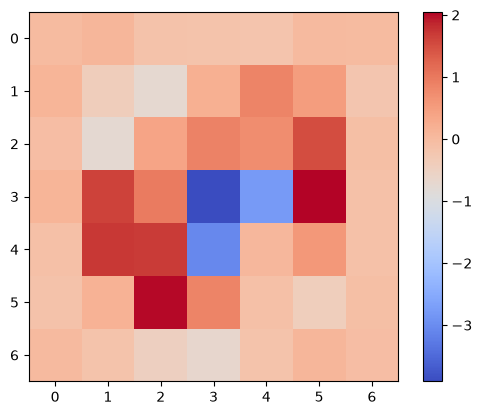

In [68]:
# コードの文法読めなくてもOK
import matplotlib.pyplot as plt
# nn.Linearの内部の重みは転置されて保存されているので、[:, 0] ではなく [0, :] で取得する
plt.imshow(model.weight[0, :].detach().reshape(7, 7), cmap="coolwarm")
plt.colorbar()
plt.savefig("images/chapter18-linear-model-weight0.png", dpi=150, bbox_inches="tight")
plt.show()

![Linear model class 0 input weights](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-linear-model-weight0.png)

かなりわかりやすく、0の形になっていることがわかります。

ただし、

## **Section 3: 隠れ層とReLUで特徴を組み合わせる**
**Mission: 画像から10種類の数字らしさを計算するモデルを作る！**


ReLUは負の値を $0$ にするため、直線1本では分けられない複雑な模様も扱えるようになります。最後の層は10個のスコアを出力します。

1. 線形変換層1：49入力 → 25出力  
   $z = XW_1 + b_1$

2. ReLU層：負の値を $0$ にする  
   $h = \operatorname{ReLU}(z)$

3. 線形変換層2：25入力 → 10出力  
   $Y = hW_2 + b_2$
   
$X$：入力画像の画素値　　$W_1, b_1$：最初の層の重みとバイアス　　$h$：隠れ層の出力  
$W_2, b_2$：最後の層の重みとバイアス　　$z$：10個の数字スコア


![hidden-layer nodes](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-hidden-layer-nodes.svg?v=302443c)

あるサンプルを学習済みモデルで順伝播した際の、全体の処理の流れを示した図です。  
今は全て理解できなくても大丈夫。すぐにわかるようになります。

とても大事な流れなので、目だけ通してください。

<img src="https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/v2samplex0forwardchapter18.png" width="1000" height="640">


それでは始めていきましょう。

まずは1層目から。

![layer 1 focus](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-layer1-focus.svg)


### Layer 1: 49個の画素を25個の値へ変換する

1枚の画像を横1行の行列 $X$ として扱います。最初の層では、49個の画素を25個の値へまとめます。

$$
\underbrace{
\begin{bmatrix}x_0 & x_1 & \cdots & x_{48}\end{bmatrix}
}_{X\ (1\times49)}
\underbrace{
\begin{bmatrix}
w_{0,0} & \cdots & w_{0,24} \\
w_{1,0} & \cdots & w_{1,24} \\
\vdots & \ddots & \vdots \\
w_{48,0} & \cdots & w_{48,24}
\end{bmatrix}
}_{W_1\ (49\times25)}
+
\underbrace{\begin{bmatrix}b_{1,0} & \cdots & b_{1,24}\end{bmatrix}}_{b_1\ (1\times25)}
=
\underbrace{\begin{bmatrix}z_0 & \cdots & z_{24}\end{bmatrix}}_{z\ (1\times25)}
$$

行列積では、$X$ の49個の値と $W_1$ の各列を内積にして、25個の結果を同時に作ります。

例えば、$z_0$ は、$W_1$ の0列目を使って次のように計算されます。

$$
z_0 = x_0 w^{(1)}_{0,0} + x_1 w^{(1)}_{1,0} + \cdots + x_{48} w^{(1)}_{48,0} + b_{1,0}
$$

つまり、49個の画素それぞれに $W_1$ の0列目の重みを掛け、その49個の積を足し合わせ、最後に $b_{1,0}$ を加えます。


In [58]:
# 重みの初期値はランダムな値として作成（PyTorchの関数を使用）
W1 = torch.randn(49, 25, requires_grad=True)
# バイアスの初期値はゼロ
b1 = torch.zeros(25, requires_grad=True)

入力画像と第1層の重み・バイアスから、25個の変換前の値を計算しましょう。

```python
出力: z（第1層の変換前の値）
式: X[0] @ W1 + b1
```


In [59]:
z = X[0] @ W1 + b1  # TODO: 出力 = 式
print_formatted_tensor("z", z)

z
Tensor Size: [25]
tensor([
         5.94,   3.04,  -3.90,   4.16,   1.21,  -1.56,  -4.53,  -3.13,   1.80,  -2.14,   3.09,   6.84,   5.93,   3.40,   0.09,   1.86,   0.76,   1.83,  -2.31,  -0.76,  -2.52,  -5.12,   2.93,   6.25,   1.24
       ], grad_fn=<AddBackward0>)


![relu 1 focus](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-relu1-focus.svg)


### ReLU 1: 負の値を0にする

次に、25個の出力値をReLU関数に通します。

$$
\underbrace{\begin{bmatrix}h_0 & \cdots & h_{24}\end{bmatrix}}_{h\ (1\times25)}
=
\operatorname{ReLU}\left(
\begin{bmatrix}z_0 & \cdots & z_{24}\end{bmatrix}
\right)
$$


第1層の変換前の値をReLU関数に通し、負の値を0にしましょう。

```python
出力: h（ReLUを通した隠れ層の出力）
関数: torch.relu
引数: z
```


In [60]:
h = torch.relu(z)  # TODO: 出力 = 関数(引数)
print_formatted_tensor("h", h)

h
Tensor Size: [25]
tensor([
         5.94,   3.04,   0.00,   4.16,   1.21,   0.00,   0.00,   0.00,   1.80,   0.00,   3.09,   6.84,   5.93,   3.40,   0.09,   1.86,   0.76,   1.83,   0.00,   0.00,   0.00,   0.00,   2.93,   6.25,   1.24
       ], grad_fn=<ReluBackward0>)


![layer 2 focus](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-layer2-focus.svg)


### Layer 2: 25個の特徴を10個のスコアへ変換する

最後の層では、25個の特徴を10個の数字スコアへ変換します。

$$
\underbrace{\begin{bmatrix}h_0 & \cdots & h_{24}\end{bmatrix}}_{h\ (1\times25)}
\underbrace{
\begin{bmatrix}
w^{(2)}_{0,0} & \cdots & w^{(2)}_{0,9} \\
\vdots & \ddots & \vdots \\
w^{(2)}_{24,0} & \cdots & w^{(2)}_{24,9}
\end{bmatrix}
}_{W_2\ (25\times10)}
+
\underbrace{\begin{bmatrix}b_{2,0} & \cdots & b_{2,9}\end{bmatrix}}_{b_2\ (1\times10)}
=
\underbrace{\begin{bmatrix}Y_0 & \cdots & Y_9\end{bmatrix}}_{Y\ (1\times10)}
$$

例えば、クラス0のスコア $Y_0$ は、$W_2$ の **0列目**だけを使って次のように計算されます。

$$
Y_0 = h_0 w^{(2)}_{0,0} + h_1 w^{(2)}_{1,0} + h_2 w^{(2)}_{2,0} + \cdots + h_{24} w^{(2)}_{24,0} + b_{2,0}
$$

つまり、25個の特徴それぞれにクラス0用の重みを掛け、その25個の積をすべて足し合わせ、最後にクラス0のバイアス $b_{2,0}$ を加えます。

$X$：入力画像　　$W_1, W_2$：学習する重み　　$b_1, b_2$：バイアス　　$Y$：10個の数字スコア


In [61]:
# 重みの初期値はランダムな値として作成（PyTorchの関数を使用）
W2 = torch.randn(25, 10, requires_grad=True)
# バイアスの初期値はゼロ
b2 = torch.zeros(10, requires_grad=True)

隠れ層の25個の値を第2層へ入力し、10個の数字スコアを計算しましょう。

```python
出力: Y_pred（10個の数字スコア）
式: h @ W2 + b2
```


In [62]:
Y_pred = h @ W2 + b2  # TODO: 出力 = 式
print_formatted_tensor("Y_pred", Y_pred)

Y_pred
Tensor Size: [10]
tensor([
         -16.92,   7.05,  -8.71,  -8.38, -11.50,  11.30,  24.66,   1.19,   1.48,   1.22
       ], grad_fn=<AddBackward0>)


1000枚の画像の場合も、計算手順は同じです。

入力`X`(1000x49)の場合

In [ ]:
z = X @ W1 + b1 # TODO: X @ W1 + b1
h = torch.relu(z) # TODO:THINK_BY_YOURSELF
Y_pred = h @ W2 + b2 # TODO:THINK_BY_YOURSELF
print_formatted_tensor("Y_pred", Y_pred)

Y_pred
Tensor Size: [1000, 10]
tensor([
         [-16.92,   7.05,  -8.71,  -8.38, -11.50,  11.30,  24.66,   1.19,   1.48,   1.22],
         [-10.45,  -1.47,  -5.33,  -7.11,  -5.18,  -5.10,   0.36,   1.88,  -3.52,  -4.30],
         [ -6.84,   5.93,   0.68,  -0.76,  -7.85,  17.17,  13.83,  10.04,  16.93,  -4.10],
         [ -6.58,  -4.18,  -2.37,   1.16,  -0.58,   0.27,   2.94,  -0.03,   3.86,   2.12],
         [ -4.27,   1.33,  -5.35,  -6.49,  -5.75,   0.85,  15.22,   0.96,  -3.32,  10.74],
         [-15.84,   1.04,   0.35,   0.63,  -5.50,   4.35,   9.14,   3.59,   7.02,  -5.70],
         [-12.88,   8.93,  -3.58,  -3.02, -11.81,   8.94,   5.41,   0.74,  14.12,  -8.07],
         [-11.96,   1.99,  -5.13,  -5.10,  -4.64,  -8.47,   9.48,   0.31,  -7.22,   0.43],
         [-14.43,   0.03,  -7.21, -10.41,  -8.79,  -0.84,  12.35,   4.14,   3.99,   6.69],
         [-13.35,   8.63,  -6.12,  -2.69, -10.15,  10.73,   0.09,   4.86,  21.15,  -5.24],
         [-10.51,   3.27,   0.66,  -2.63,  -6.19, 

In [57]:
Y_prob = torch.softmax(Y_pred, dim=1)
print_formatted_tensor("Y_prob", Y_prob)

Y_prob
Tensor Size: [1000, 10]
tensor([
         [  0.81,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.19],
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   1.00],
         [  0.00,   0.00,   0.89,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.11],
         [  0.01,   0.00,   0.00,   0.00,   0.00,   0.00,   0.49,   0.00,   0.00,   0.49],
         [  0.00,   0.00,   0.00,   0.00,   0.21,   0.00,   0.00,   0.00,   0.00,   0.79],
         [  0.00,   0.00,   0.69,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.31],
         [  0.02,   0.00,   0.00,   0.00,   0.00,   0.00,   0.96,   0.00,   0.00,   0.01],
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   1.00],
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   1.00],
         [  0.02,   0.00,   0.00,   0.00,   0.04,   0.00,   0.91,   0.00,   0.00,   0.03],
         [  0.00,   0.00,   0.01,   0.00,   0.01, 

## **Section 4: モデルをクラスとして定義する**
**Mission: 49 → 25 → 10 の計算を、ひとつのモデルとしてまとめる！**


今までは、49入力 → 10出力の、1層の線形変換モデル $Y=XW$ でした。（バイアスなし）

そのため、`model = nn.Linear(49, 10, bias=False)` という、とても単純なコードでした。

PyTorchのクラス`nn.Linear`をそのまま使えました。

<br>

しかし、今回のような クラスはデフォルトで提供されていません。

そこで、複数の層を順番にまとめたクラスを自作します。

クラスの作り方を忘れてしまった方は、今ここで復習しましょう。


![NeuralNetwork structure](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-class-network.svg)


```python
# モデルのクラスは主に、初期化メソッドと、順伝播のメソッドの2つのメソッドを持ちます。
class NeuralNetwork():
    # クラスの初期化メソッドは、変数を登録します。
    def __init__(self):
        self.W1 = torch.randn(49, 25, requires_grad=True)
        self.b1 = torch.zeros(25, requires_grad=True) 
        self.W2 = # TODO: 出力=式
        self.b2 = # TODO: 出力=式

    # 順伝播のメソッドは、入力を受け取り、出力を返します。
    def forward(self, X):
        # 予測する
        z = X @ self.W1 + self.b1
        h = # TODO: 出力 = 関数(引数). 出力の変数名はh
        Y_pred = # TODO: 出力 = 式
        return Y_pred
```

上記を参考に、クラスのコードを写経してください。

TODO部分は、自分で考えて埋めましょう。

In [49]:
########## WRITE  ########## 
class NeuralNetwork():
    def __init__(self):
        self.W1 = torch.randn(49, 25, requires_grad=True)
        self.b1 = torch.zeros(25, requires_grad = True)
        self.W2 = torch.randn(25, 10, requires_grad=True)
        self.b2 = torch.zeros(10, requires_grad=True)

    def forward(self, X):
        z = X @ self.W1 + self.b1
        h = torch.relu(z)
        Y_pred = h @ self.W2 + self.b2
        return Y_pred











########## WRITE  ########## 

必ず正解と確認してください。

```python
# モデルのクラスは主に、初期化メソッドと、順伝播のメソッドの2つのメソッドを持ちます。
class NeuralNetwork():
    # クラスの初期化メソッドは、変数を登録します。
    def __init__(self):
        self.W1 = torch.randn(49, 25, requires_grad=True)
        self.b1 = torch.zeros(25, requires_grad=True) 
        self.W2 = torch.randn(25, 10, requires_grad=True) # TODO: 出力=式
        self.b2 = torch.zeros(10, requires_grad=True) # TODO: 出力=式

    # 順伝播のメソッドは、入力を受け取り、出力を返します。
    def forward(self, X):
        # 予測する
        z = X @ self.W1 + self.b1
        h = torch.relu(z) # TODO: 出力 = 関数(引数)
        Y_pred = h @ self.W2 + self.b2 # TODO: 出力 = 式
        return Y_pred
```

定義した `NeuralNetwork` クラスから、学習に使うニューラルネットワークを作りましょう。

```python
インスタンス: nn_model（49 → 25 → 10 のニューラルネットワーク）
クラス: NeuralNetwork
引数: なし
```


In [50]:
# PyTorchのランダム性を管理するコード(気にしなくてOK)
torch.manual_seed(0)
# ニューラルネットワークのインスタンスを作成
nn_model = NeuralNetwork()  # TODO: インスタンス = クラス(引数)

インスタンス内部の変数`self.W1`には、`nn_model.W1`でアクセスします。

In [51]:
print_formatted_tensor(nn_model.W1)

Tensor Size: [49, 25]
tensor([
         [ -1.13,  -1.15,  -0.25,  -0.43,   0.85,   0.69,  -0.32,  -2.12,   0.32,  -1.26,   0.35,   0.31,   0.12,   1.24,   1.12,  -0.25,  -1.35,  -1.70,   0.57,   0.79,   0.60,  -1.56,  -0.34,   1.85,   0.75],
         [ -0.59,  -0.17,   0.18,   1.39,   1.59,   0.95,  -0.84,  -0.61,   0.03,  -0.49,   0.25,   0.44,   0.11,   0.64,   0.44,  -0.10,   0.79,  -0.29,   0.05,   0.52,   2.30,  -1.47,  -1.59,  -0.67,   0.87],
         [  1.06,   0.18,  -0.23,  -0.39,   0.54,  -0.40,  -0.45,   0.74,   1.52,   3.41,  -1.53,  -1.23,   1.82,  -0.55,  -0.57,   0.92,   1.11,   1.29,  -1.48,   2.57,  -0.47,   0.34,  -1.63,  -0.55,  -0.48],
         [ -0.50,  -1.07,   1.11,  -0.14,   0.81,  -0.09,   0.69,  -0.84,   0.00,   0.84,  -0.40,   1.04,   0.36,  -0.25,   2.30,  -1.88,  -0.05,  -1.04,  -0.96,   0.03,   0.71,   1.65,  -1.36,   0.34,   0.52],
         [ -2.61,  -1.70,  -0.23,   0.28,   0.25,   0.08,   0.34,   0.45,   0.46,  -0.87,   0.78,  -0.93,  -0.22,  -2.44,  -0

In [52]:
print_formatted_tensor(nn_model.b1)

Tensor Size: [25]
tensor([
         0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00
       ], requires_grad=True)


In [53]:
print_formatted_tensor(nn_model.W2)  # TODO: nn_modelインスタンスのW2を表示する

Tensor Size: [25, 10]
tensor([
         [ -1.30,   0.35,   0.26,  -0.10,   0.28,   0.01,  -0.29,   1.68,   0.94,  -1.47],
         [ -0.04,  -0.70,   0.10,  -0.55,  -0.75,  -1.44,  -0.02,  -1.23,   2.19,   0.22],
         [  1.14,  -2.11,   0.47,   1.44,  -0.11,  -1.33,  -0.04,  -0.14,  -0.55,   0.87],
         [ -0.26,   0.31,  -0.68,  -0.90,  -0.64,   0.11,  -0.51,  -1.08,   1.67,  -0.35],
         [  0.26,  -0.44,  -0.68,  -2.55,   1.55,   1.51,  -0.94,   0.39,  -0.13,   1.53],
         [  1.55,  -0.83,  -1.01,   0.02,   0.34,   0.81,   0.56,  -1.14,   1.12,   0.39],
         [ -0.07,  -0.53,  -0.23,  -1.30,   1.04,  -0.45,   0.23,   0.33,   0.73,   1.99],
         [ -0.75,  -1.12,   1.21,  -0.65,  -0.51,   0.01,   0.98,  -2.11,  -0.69,   0.22],
         [  0.19,  -0.63,   0.52,   0.18,  -0.53,   0.01,  -0.42,  -0.15,   1.32,   0.84],
         [  0.25,  -0.18,  -1.80,   1.08,   0.76,  -0.95,  -0.60,   1.28,   1.19,  -0.62],
         [  1.39,  -0.20,   2.33,   0.82,   0.63,  -0.60,  

In [54]:
print_formatted_tensor(nn_model.b1) # TODO: nn_modelインスタンスのb1を表示する

Tensor Size: [25]
tensor([
         0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00
       ], requires_grad=True)


入力画像すべてをモデルに渡し、各画像に対する10個の数字スコアを予測しましょう。

```python
出力: Y_pred（1000枚の画像に対する10個の数字スコア）
インスタンス: nn_model
メソッド: forward
引数: X
```


In [55]:
Y_pred = nn_model.forward(X)  # TODO: 出力 = インスタンス.メソッド(引数)
print_formatted_tensor("Y_pred", Y_pred)

Y_pred
Tensor Size: [1000, 10]
tensor([
         [ 14.38, -14.93,   7.27,   4.98,   4.45,   1.89,   8.38,  -1.31,   3.07,  12.93],
         [ -0.99, -20.98,   3.76,  -4.09,   1.30,  -5.88,  11.48,  -6.24,  -4.31,  17.38],
         [ 11.05, -17.94,  22.58,   9.38,   0.07,   2.99,   4.42, -13.18,  -2.52,  20.52],
         [  8.04, -13.52,   0.05,   0.28,   5.56,   1.17,  11.84,  -5.38,   3.47,  11.83],
         [  3.53,  -9.64,  -6.81, -14.12,  14.51,   8.25,  10.30,   5.89,  -1.92,  15.82],
         [  8.63, -22.58,  15.77,   5.41,   2.90,  -3.09,   7.10, -11.21,  -0.35,  14.98],
         [ 10.53, -26.79,   1.71,   4.70,   8.50,   0.12,  14.29, -12.73,   8.95,   9.88],
         [  6.66, -20.20,   5.86,   0.18,   3.51,  -2.84,   3.37,  -2.90,  -1.50,  14.35],
         [  8.84,  -7.44,   8.44,  -0.06,   4.11,  -0.52,  10.89,   4.51,  -3.74,  16.96],
         [  8.52, -22.46,   4.46,   2.77,   9.12,  -7.60,  12.22,  -8.97,   1.58,   8.64],
         [  3.05, -10.89,   5.74,  -3.22,   5.52, 

## **Section 5: 訓練開始**


学習によってモデルの重みを更新するため、SGDオプティマイザを作成します。

```python
インスタンス: optimizer（パラメータを更新する最適化手法）
クラス: optim.SGD
引数: [nn_model.W1, nn_model.b1, nn_model.W2, nn_model.b2], lr=0.1
```

ヒント: 4つの学習パラメータをリストにまとめて、`optim.SGD`へ渡します。

In [33]:
import torch.optim as optim
optimizer = optim.SGD([nn_model.W1, nn_model.b1, nn_model.W2, nn_model.b2], lr=0.1)  # TODO: インスタンス = クラス(引数)

モデルは10個のスコアを予測し、Cross Entropyでそのずれを損失 $L$ として計算します。

```python
インスタンス: criterion（予測と正解のずれを測る損失関数）
クラス: nn.CrossEntropyLoss
引数: reduction="mean"
```

ヒント: クラスに`reduction="mean"`を指定して作成します。

In [34]:
import torch.nn as nn
criterion = nn.CrossEntropyLoss(reduction="mean")  # TODO: インスタンス = クラス(引数)
print(criterion)

CrossEntropyLoss()


`criterion`を使って、予測スコア`Y_pred`と正解ラベル`y`から損失を計算します。

```python
出力: loss（平均損失）
インスタンス: criterion
メソッド: forward
引数: Y_pred, y
```

ヒント: `criterion.forward(Y_pred, y)`の戻り値を`loss`に代入します。

In [35]:
loss = criterion.forward(Y_pred, y)  # TODO: 出力 = インスタンス.メソッド(引数)
print("loss", loss)

loss tensor(13.0961, grad_fn=<NllLossBackward0>)


ここまでをまとめて、モデルを学習させます。

In [ ]:
torch.manual_seed(0)

########## NEW ##########
nn_model = NeuralNetwork()
########## NEW ##########
"""DELETE
model = nn.Linear(784, 10, bias=False)
"""
    
criterion = nn.CrossEntropyLoss(reduction="mean")
########## NEW ##########
optimizer = optim.SGD([nn_model.W1, nn_model.b1, nn_model.W2, nn_model.b2], lr=0.1)
########## NEW ##########
"""DELETE
optimizer = optim.SGD([model.weight], lr=1.0)
"""

num_epochs = 10000
for epoch in range(num_epochs):

    # 予測する
    Y_pred = nn_model.forward(X)

    # 損失を計算する
    loss = criterion.forward(Y_pred, y)

    optimizer.zero_grad() # TODO: optimizerの勾配を初期化する
    loss.backward() # TODO: lossに対する勾配(W2,b2,W1,b1の各変数よる偏微分)を逆伝播で計算する
    optimizer.step() # TODO: optimizerのパラメータを更新する

    print("epoch", epoch, "loss", loss)


epoch 0 loss tensor(13.0961, grad_fn=<NllLossBackward0>)
epoch 1 loss tensor(10.6465, grad_fn=<NllLossBackward0>)
epoch 2 loss tensor(9.2834, grad_fn=<NllLossBackward0>)
epoch 3 loss tensor(8.3802, grad_fn=<NllLossBackward0>)
epoch 4 loss tensor(7.7517, grad_fn=<NllLossBackward0>)
epoch 5 loss tensor(7.2793, grad_fn=<NllLossBackward0>)
epoch 6 loss tensor(6.8904, grad_fn=<NllLossBackward0>)
epoch 7 loss tensor(6.5506, grad_fn=<NllLossBackward0>)
epoch 8 loss tensor(6.2430, grad_fn=<NllLossBackward0>)
epoch 9 loss tensor(5.9624, grad_fn=<NllLossBackward0>)
epoch 10 loss tensor(5.7038, grad_fn=<NllLossBackward0>)
epoch 11 loss tensor(5.4652, grad_fn=<NllLossBackward0>)
epoch 12 loss tensor(5.2450, grad_fn=<NllLossBackward0>)
epoch 13 loss tensor(5.0409, grad_fn=<NllLossBackward0>)
epoch 14 loss tensor(4.8507, grad_fn=<NllLossBackward0>)
epoch 15 loss tensor(4.6746, grad_fn=<NllLossBackward0>)
epoch 16 loss tensor(4.5107, grad_fn=<NllLossBackward0>)
epoch 17 loss tensor(4.3580, grad_fn=<N

**`Check Point`**
<label><input type="checkbox">lossが継続的に下がったことを確認した</label>

In [ ]:
# 訓練済みモデルで予測する
Y_pred = nn_model.forward(X)
# 予測結果を確率に変換する
Y_pred_prob = torch.softmax(Y_pred, dim=1)
# 確率が最大のクラスを予測結果のクラスとして取得する
Y_pred_class = torch.argmax(Y_pred_prob, dim=1)
# 正解数を計算する
num_correct = torch.sum(Y_pred_class == y)
# 正解率を計算する
accuracy = num_correct / len(y)
print("正解率:", accuracy)

正解率: tensor(0.9390)


**`Check Point`**
<label><input type="checkbox">正解率が単純な線型層の時よりも高いことを確認した</label>

## **Section 6: 学習した重みと隠れ層の特徴を見る**
**Mission: 隠れ層がどんな画像の特徴を見つけたか確かめる！**

モデルの学習が完了しました。ここで、学習済みのパラメータについて解釈を行なっていきます。    
これはモデルの解釈性であり、`Interpretibity` と呼ばれる一大分野にも繋がります。 

まず、大前提として、機械学習済みモデルのパラメータにする解釈は、まず困難であること。    
そして、運良く解釈できたとしても、別の解釈が生まれる可能性が高いこと。この2つに注意してください。

お堅い前置きはここまでにして、実際にモデルのパラメータの中身を見ていきましょう。    
ついに深層学習モデルの本当に面白い部分へとやってきました！



まずは、すべてのパラメータをprintして、中身を見てみます。

In [ ]:
print_formatted_tensor(nn_model.W1)


Tensor Size: [49, 25]
tensor([
         [ -1.13,  -1.15,  -0.25,  -0.43,   0.85,   0.69,  -0.32,  -2.12,   0.32,  -1.26,   0.35,   0.31,   0.12,   1.24,   1.12,  -0.25,  -1.35,  -1.70,   0.57,   0.79,   0.60,  -1.56,  -0.34,   1.85,   0.75],
         [ -0.59,  -0.17,   0.18,   1.39,   1.59,   0.95,  -0.84,  -0.61,   0.03,  -0.49,   0.25,   0.44,   0.11,   0.64,   0.44,  -0.10,   0.79,  -0.29,   0.05,   0.52,   2.30,  -1.47,  -1.59,  -0.67,   0.87],
         [  1.01,   0.19,  -0.25,  -0.40,   0.53,  -0.42,  -0.45,   0.88,   1.55,   3.35,  -1.51,  -1.23,   1.87,  -0.75,  -0.57,   0.99,   1.11,   1.29,  -1.48,   2.60,  -0.46,   0.34,  -1.53,  -0.55,  -0.48],
         [ -0.49,  -1.06,   1.11,  -0.15,   0.73,  -0.60,   0.68,  -0.47,  -0.15,   0.84,  -0.64,   0.91,   0.39,  -1.22,   2.50,  -1.10,  -0.24,  -1.04,  -0.96,  -0.37,   1.22,   1.58,  -0.47,   0.34,   0.52],
         [ -2.60,  -1.70,  -0.58,   0.26,   0.23,   0.13,   0.34,   0.80,   0.79,  -0.87,   0.52,  -0.93,  -0.22,  -2.54,  -0

In [ ]:
print_formatted_tensor(nn_model.b1)

Tensor Size: [25]
tensor([
         -0.10,  -0.41,  -0.19,  -0.13,  -0.35,   0.27,  -0.53,  -0.07,   0.84,  -0.55,  -0.18,   0.02,   0.05,   0.62,   0.80,   0.08,   0.58,  -0.78,  -0.19,   0.00,  -0.17,  -0.36,   0.74,  -0.80,  -1.17
       ], requires_grad=True)


In [ ]:
print_formatted_tensor(nn_model.W2)

Tensor Size: [25, 10]
tensor([
         [ -1.79,   0.96,   1.93,  -0.61,  -0.20,  -0.81,  -0.58,   2.22,   1.23,  -1.99],
         [  0.03,  -0.34,   0.68,  -0.55,  -0.80,  -1.55,  -0.36,  -1.23,   1.86,   0.04],
         [  0.89,  -1.91,  -0.01,   1.84,  -1.22,  -0.61,   0.55,   0.47,  -1.41,   1.04],
         [  0.11,   2.39,  -0.52,  -2.28,  -1.63,   1.61,  -0.89,  -1.02,  -0.60,   0.52],
         [  0.20,  -0.47,  -0.34,  -2.51,   1.25,   1.54,  -0.88,   0.24,  -0.18,   1.65],
         [  1.55,  -1.52,  -1.50,   0.23,   1.27,   0.49,  -0.50,   0.21,   1.39,   0.19],
         [ -0.07,  -0.55,  -0.27,  -1.30,   1.04,  -0.46,   0.17,   0.33,   1.11,   1.73],
         [  0.08,  -0.16,   1.08,   0.11,  -0.96,  -0.22,   1.65,  -3.17,  -0.42,  -1.39],
         [ -1.34,   0.98,  -1.41,  -0.31,  -0.24,   0.53,   0.46,   0.05,   1.64,   0.96],
         [ -0.22,   0.12,  -1.93,   1.30,   1.57,  -1.11,  -0.85,   1.31,   0.91,  -0.70],
         [  1.21,  -2.21,  -0.95,   1.35,   1.50,   2.60,  

In [ ]:
print_formatted_tensor(nn_model.b2)

Tensor Size: [10]
tensor([
         -0.05,   0.60,  -0.65,  -0.01,   0.03,  -0.23,   0.68,   0.21,   0.16,  -0.74
       ], requires_grad=True)


ここまでだと、何もわからないですね。

試しに、特定のサンプルを順伝播させてみます。

<img src="https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-X3.png" width="250">


ちなみに、最初の結果を示すと、以下のようになります。

<img src="https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/v2samplex0forwardchapter18.png" width="1000" height="640">

In [ ]:
x3 = X[3]
print_formatted_tensor(x3)

Tensor Size: [49]
tensor([
         0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.13,   0.94,   0.31,   0.00,   0.00,   0.00,   0.12,   0.73,   0.00,   0.98,   0.00,   0.00,   0.00,   0.94,   0.00,   0.01,   0.66,   0.00,   0.00,   0.77,   0.00,   0.01,   0.88,   0.00,   0.00,   0.00,   0.99,   0.72,   0.64,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00
       ])


入力画像`x3`を第1層に通し、25個の値を計算します。

```python
出力: z（第1層の線形変換結果）
式: x3 @ nn_model.W1 + nn_model.b1
```

`x3`、重み`W1`、バイアス`b1`の行列積と加算によって、隠れ層へ渡す値を求めます。

In [ ]:
# 第1層: (1, 49) @ (49, 25) + (25) -> (25)
z = x3 @ nn_model.W1 + nn_model.b1  # TODO: 出力 = 式
print_formatted_tensor(z)

Tensor Size: [25]
tensor([
         -4.26,  -2.24,   4.21,   0.51,  -7.23,   8.19,  -4.29,   8.69,   1.46,   1.53,  -1.97,  -1.38,  -4.85,   5.15,   1.31,  -2.60,   4.95,   1.53,  -4.83,  -0.34,  -1.73,  -4.01,   3.57,  -7.46,  -2.25
       ], grad_fn=<AddBackward0>)


第1層の出力にReLUを適用し、負の値を0に変換します。

```python
出力: h（ReLU後の隠れ層の値）
関数: torch.relu
引数: z
```

In [ ]:
# 活性化層: 負の値を0にする
h = torch.relu(z)  # TODO: 出力 = 関数(引数)
print_formatted_tensor(h)

Tensor Size: [25]
tensor([
         0.00,   0.00,   4.21,   0.51,   0.00,   8.19,   0.00,   8.69,   1.46,   1.53,   0.00,   0.00,   0.00,   5.15,   1.31,   0.00,   4.95,   1.53,   0.00,   0.00,   0.00,   0.00,   3.57,   0.00,   0.00
       ], grad_fn=<ReluBackward0>)


ReLU後の25個の特徴を第2層へ入力し、10クラス分のスコアを計算します。

```python
出力: Y_pred（10クラスのスコア）
式: h @ nn_model.W2 + nn_model.b2
```

25個の特徴を重み`W2`で10個のスコアへ変換し、バイアス`b2`を加えます。

In [ ]:
# 第2層: (1, 25) @ (25, 10) + (10) -> (10)
Y_pred = h @ nn_model.W2 + nn_model.b2  # TODO: 出力 = 式
print_formatted_tensor(Y_pred)

Tensor Size: [10]
tensor([
         17.56, -12.68,   3.86,  12.34,   3.11,   9.80,   3.44, -20.38,  -4.64,  -7.53
       ], grad_fn=<AddBackward0>)


10クラス分のスコアを、合計が1になる確率へ変換します。

```python
出力: Y_prob（各クラスの予測確率）
関数: THINK_BY_YOURSELF
引数: THINK_BY_YOURSELF, dim=THINK_BY_YOURSELF
```

In [ ]:
Y_prob = torch.softmax(Y_pred, dim=0)  # TODO: 出力 = 関数(引数)
print_formatted_tensor(Y_prob)

Tensor Size: [10]
tensor([
         0.99,   0.00,   0.00,   0.01,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00
       ], grad_fn=<SoftmaxBackward0>)


こうして、予測がクラス0になるわけです。

ここからは、クラス0を認識するパラメータ対象を絞って、重みの分析を行います。

下図を参考にして、隠れ層hについて、大きな値をもつノード上位5つ探してください。    
上から順に、node0, node1....node24 と並んでいます。

<img src="https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/v2samplex0forwardchapter18.png" width="1000" height="640">


上記の図を見ると、h について大きな値をもつ上位5つのノードは、`node0`~`node24`の25個のノードのうち、

`node2`, `node5`, `node13`, `node16`, `node22` の5つであることがわかります。

入力の重み `W1` について着目します。

49個の入力 $X$ のどこに着目しているのでしょうか。

例えば、`node2` がどの入力に着目しているかは、$W_1$ の列2（3列目）に対応します。

$$
h_2 =
\underbrace{\begin{bmatrix}x_0 & x_1 & \cdots & x_{48}\end{bmatrix}}_{X\ (1\times49)}
\cdot
\underbrace{\boxed{\begin{bmatrix}
w^{(1)}_{0,2} \\
w^{(1)}_{1,2} \\
\vdots \\
w^{(1)}_{48,2}
\end{bmatrix}}}_{W_1[:,2]\ （node2に対応する列）}
+ b_{1,2}
$$

対応する要素を展開すると、次の49個の積を足し合わせています。

$$
h_2 = x_0 w^{(1)}_{0,2} + x_1 w^{(1)}_{1,2} + \cdots + x_{48} w^{(1)}_{48,2} + b_{1,2}
$$

In [ ]:
print_formatted_tensor(nn_model.W1[:, 2])

Tensor Size: [49]
tensor([
         -0.25,   0.18,  -0.25,   1.11,  -0.58,   1.39,   0.19,  -0.36,   0.93,   1.31,  -0.67,   0.57,   0.39,  -0.84,   0.51,  -0.73,  -0.04,   1.52,   3.36,   1.10,  -1.16,   0.81,   0.51,  -0.52,   0.72,   0.20,   0.15,   0.65,   0.41,  -0.18,  -1.49,  -0.16,   0.31,   0.65,   0.25,  -0.04,   1.05,   1.04,   0.19,  -1.13,  -0.47,  -1.30,  -1.50,   0.92,   0.86,   1.00,   1.56,   0.18,  -0.45
       ], grad_fn=<SelectBackward0>)


18番目の値がかなり高いのですが、流石に見づらいと思います。

7x7の形で可視化します。

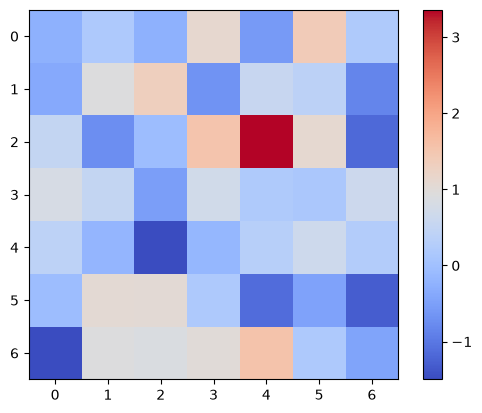

In [ ]:
# コードの文法読めなくてもOK
import matplotlib.pyplot as plt
plt.imshow(nn_model.W1[:, 2].detach().reshape(7, 7), cmap="coolwarm")
plt.colorbar()
plt.show()

このように、特定のピクセルだけに着目するような重みができます。

49 -> 10 の線形変換モデルでは、数字の形の通りに注目するだけでした。

隠れ層を挟むことによって、中間的な特徴をモデルは学習できるようになります。

すべてのノードについて、どこの重みに着目しているかを確認しましょう。

それぞれのノードが、異なるピクセルに注目していることが分かります。

![All hidden node input weights](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-all-node-input-weights.png)

ここでピックアップしたいのが、先ほども注目したノードのうちの1つ、`ノード16`です。

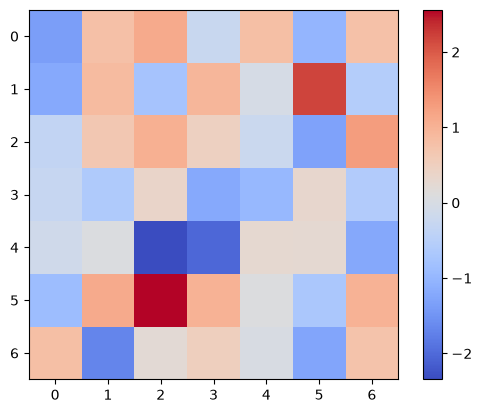

In [ ]:
# コードの文法読めなくてもOK
import matplotlib.pyplot as plt
plt.imshow(nn_model.W1[:, 16].detach().reshape(7, 7), cmap="coolwarm")
plt.colorbar()
plt.show()

0 の数字の右上と左下に対応するかのごとく、着目しています。

このように、時々、解釈がしやすいような特徴もあります。


なお後付けにはなってしまいますが、`ノード16`の値 $h_{16}$ は、クラス0と、0以外のクラスにおける差がもっとも大きいノードです。

クラス0の画像に対しては大きな値を持つ傾向にありますが、0以外のクラスの画像に対しては値はReLUを通って0になる傾向があります。。

そのため、`ノード16` は0特有の特徴を抜き出している可能性が高いかもしれません。

![Mean hidden activation](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-mean-hidden-activation.png)

同じサンプルを、隠れ層を持たない訓練済みモデル`49 → 10`にも入力してみます。入力画像、49個の画素、10個のスコア、Softmax後の確率を横方向に並べて、線形モデルの順伝播を確認します。

In [ ]:
# 同じサンプルを、訓練済みの49 -> 10線形モデルに入力する
import matplotlib.pyplot as plt

sample_index = torch.where(y == 0)[0][0].item()
x_one = X[sample_index]
with torch.no_grad():
    logits_linear = model.forward(x_one)
    probabilities_linear = torch.softmax(logits_linear, dim=0)

input_limit = x_one.max().item()
logit_limit = logits_linear.abs().max().item()
predicted_class_linear = logits_linear.argmax().item()

def draw_linear_vector(ax, values, title, vmin, vmax, colorbar_label, figure):
    values = values.detach().cpu()
    image = ax.imshow(values.unsqueeze(1), cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(title, fontsize=18, pad=22)
    ax.set_xticks([])
    ax.set_yticks([])
    threshold = (vmin + vmax) / 2
    for index, value in enumerate(values):
        text_color = "white" if value.item() > threshold else "black"
        ax.text(0, index, f"{value.item():.2f}", ha="center", va="center", fontsize=10, color=text_color)
    colorbar = figure.colorbar(image, ax=ax, orientation="vertical", pad=0.22, fraction=0.10)
    colorbar.set_label(colorbar_label, fontsize=13, labelpad=14)
    colorbar.ax.tick_params(labelsize=10)

fig_linear = plt.figure(figsize=(22, 24))
grid_linear = fig_linear.add_gridspec(98, 4, width_ratios=[16, 3, 3, 3], wspace=2.4)
axes_linear = [
    fig_linear.add_subplot(grid_linear[42:56, 0]),  # 元画像
    fig_linear.add_subplot(grid_linear[:, 1]),      # 入力49個
    fig_linear.add_subplot(grid_linear[39:59, 2]),  # logit 10個
    fig_linear.add_subplot(grid_linear[39:59, 3]),  # 確率10個
]

input_image = axes_linear[0].imshow(x_one.reshape(7, 7), cmap="gray", vmin=0, vmax=input_limit)
axes_linear[0].set_title(f"Input image\ntrue label: {y[sample_index].item()}", fontsize=18, pad=22)
axes_linear[0].set_xticks([])
axes_linear[0].set_yticks([])
input_colorbar = fig_linear.colorbar(input_image, ax=axes_linear[0], orientation="vertical", pad=0.22, fraction=0.10)
input_colorbar.set_label("pixel value", fontsize=13, labelpad=14)
input_colorbar.ax.tick_params(labelsize=10)

draw_linear_vector(axes_linear[1], x_one, r"Input: $X$ (49 pixels)", 0, input_limit, "pixel value", fig_linear)
draw_linear_vector(axes_linear[2], logits_linear, "Output (10 logits)\n" r"$Y_{\mathrm{pred}}$" "\n\n", -logit_limit, logit_limit, "logit", fig_linear)
draw_linear_vector(axes_linear[3], probabilities_linear, f"Softmax probabilities\npredicted: {predicted_class_linear}" "\n\n", 0, 1, "probability", fig_linear)

arrow_formulas_linear = [None, r"$Y_{\mathrm{pred}} = XW$", r"$p = \mathrm{softmax}(Y_{\mathrm{pred}})$"]
fig_linear.canvas.draw()
for left, right, formula in zip(axes_linear[:-1], axes_linear[1:], arrow_formulas_linear):
    left_box = left.get_position()
    right_box = right.get_position()
    x_position = (left_box.x1 + right_box.x0) / 2
    fig_linear.text(x_position, 0.52, r"$\longrightarrow$", ha="center", va="center", fontsize=42)
    if formula is not None:
        fig_linear.text(x_position, 0.59, formula, ha="center", va="bottom", fontsize=17)

fig_linear.suptitle("How one class-0 image flows through the trained 49-to-10 linear model", fontsize=26, y=0.99)
plt.savefig("images/chapter18-linear-flow.png", dpi=150, bbox_inches="tight")
plt.show()

![49 to 10 linear model flow](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-linear-flow.png)